# 📡 Telecom X Parte 2 — Predicción de Churn (Cancelación de Clientes)

**Estructura del notebook:**
1. Carga y exploración inicial
2. Preparación de los datos
3. Correlación y selección de variables
4. Modelado predictivo
5. Interpretación y conclusiones

---
## 1. 📦 Importación de Librerías y Carga de Datos

In [10]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [11]:
# Carga del dataset y normalización

df_raw = pd.read_csv('datos_tratados.csv')

for col in ['customer', 'phone', 'internet', 'account']:
    df_raw[col] = df_raw[col].apply(ast.literal_eval)

df = pd.concat([
    df_raw[['customerID', 'Churn']],
    pd.json_normalize(df_raw['customer']),
    pd.json_normalize(df_raw['phone']),
    pd.json_normalize(df_raw['internet']),
    pd.json_normalize(df_raw['account'])
], axis=1)

# Charges.Total viene como string; se convierte a numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print(f'Forma del dataset: {df.shape}')
df.head(3)

Forma del dataset: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [12]:
# Exploración inicial

print('=== Tipos de datos ===')
print(df.dtypes)
print('\n=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Estadísticas numéricas ===')
df.describe()

=== Tipos de datos ===
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total       float64
dtype: object

=== Valores nulos ===
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV     

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


---
## 2. 🛠️ Preparación de los Datos

In [13]:
# Se eliminan columnas sin valor predictivo

df = df.drop(columns=['customerID'])
print(f'Columnas restantes: {df.shape[1]}')
print(df.columns.tolist())

Columnas restantes: 20
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [14]:
# Se tratan los valores nulos (churn) ya que no suman importancia para el entrenamiento

df = df.dropna(subset=['Churn'])

df = df.assign(Churn=df['Churn'].map({'Yes': 1, 'No': 0}))

median_total = df['Charges.Total'].median()
df = df.assign(**{'Charges.Total': df['Charges.Total'].fillna(median_total)})

print(f'Registros tras limpieza: {len(df)}')
print(f'Nulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Registros tras limpieza: 7043
Nulos restantes:
Series([], dtype: int64)


In [15]:
# Codificación de variables categóricas (One Hot Encoding)

cat_cols = [col for col in df.columns if df[col].dtype == object]
print(f'Columnas categóricas a codificar: {cat_cols}')

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_enc['Churn'] = df_enc['Churn'].astype(int)

print(f'\nDimensiones tras encoding: {df_enc.shape}')
df_enc.head(3)

Columnas categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dimensiones tras encoding: (7043, 31)


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Distribución de clases
  No cancelaron (0):  5174  (73.5%)
  Cancelaron    (1):  1869  (26.5%)


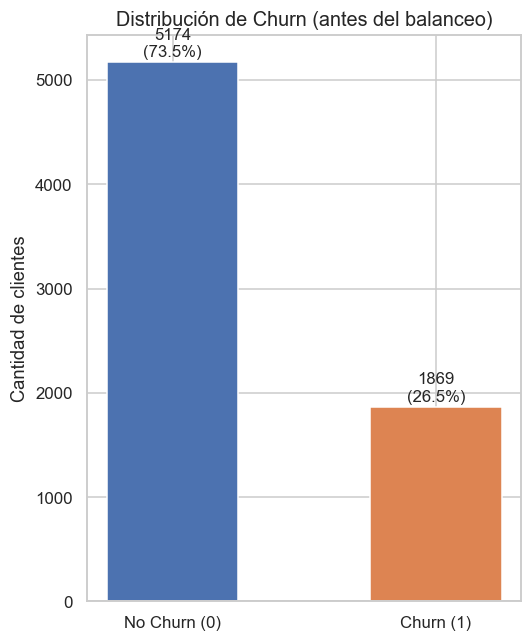


Existe un desbalance moderado (~73% vs ~27%).
Se aplicará oversampling para balancear las clases.


In [18]:
# Análisis de desbalance de clases: Churn como clase minoritaria

conteo  = df_enc['Churn'].value_counts()
porcentaje = df_enc['Churn'].value_counts(normalize=True) * 100

print('Distribución de clases')
print(f'  No cancelaron (0): {conteo[0]:>5}  ({porcentaje[0]:.1f}%)')
print(f'  Cancelaron    (1): {conteo[1]:>5}  ({porcentaje[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 6))
ax.bar(['No Churn (0)', 'Churn (1)'], conteo.values,
       color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(conteo.values, porcentaje.values)):
    ax.text(i, v + 50, f'{v}\n({p:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribución de Churn (antes del balanceo)', fontsize=13)
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

print('\nExiste un desbalance moderado (~73% vs ~27%).')
print('Se aplicará oversampling para balancear las clases.')

In [17]:
# Balanceo de clases. Se usa Oversampling por la cantidad de registros. Se utilizará sklearn.utils.resample

df_majority = df_enc[df_enc['Churn'] == 0]
df_minority = df_enc[df_enc['Churn'] == 1]

df_minority_up = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_up]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print('=== Distribución tras balanceo ===')
print(df_balanced['Churn'].value_counts())
print(f'\nTotal de registros: {len(df_balanced)}')

=== Distribución tras balanceo ===
Churn
1    5174
0    5174
Name: count, dtype: int64

Total de registros: 10348


---
## 3. 🎯 Correlación y Selección de Variables

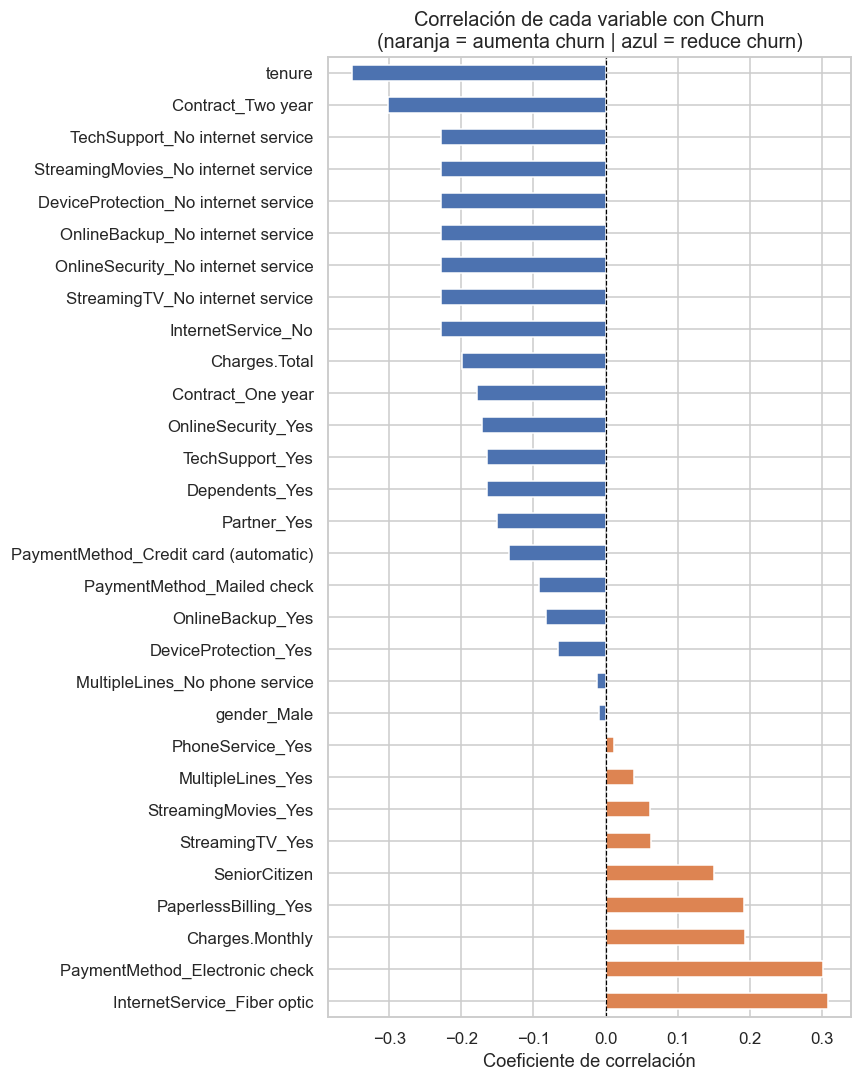

InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
Charges.Monthly                          0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226
Contract_One year                       -0.177820


In [20]:
# Matriz de correlación para detectar correlaciones fuertes entre variables

churn_corr = (
    df_enc.corr(numeric_only=True)['Churn']
    .drop('Churn')
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in churn_corr.values]

churn_corr.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlación de cada variable con Churn\n(naranja = aumenta churn | azul = reduce churn)', fontsize=13)
ax.set_xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.show()

print(churn_corr.to_string())

C:\Users\david\AppData\Local\Temp\ipykernel_40848\1742864292.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


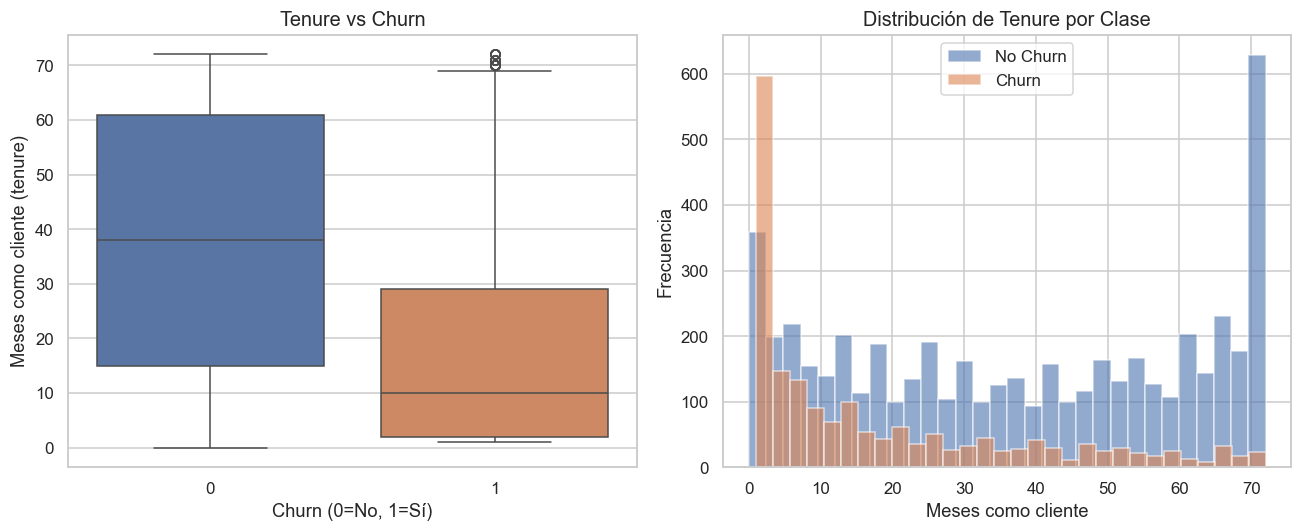

In [26]:
# Según se ha visto en la matriz de correlación, los clientes con mayor tiempo de permanecia
# son los que impactan menos en el churn, sin embargo, tambien se debe tomar en cuenta 
# el servicio de fibra optica ya que es el que impacta mas en el churn

#### Tenure

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df_enc, x='Churn', y='tenure',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0]
)
axes[0].set_title('Tenure vs Churn', fontsize=13)
axes[0].set_xlabel('Churn (0=No, 1=Sí)')
axes[0].set_ylabel('Meses como cliente (tenure)')

# Distribución
for churn_val, color, label in [(0, '#4C72B0', 'No Churn'), (1, '#DD8452', 'Churn')]:
    subset = df_enc[df_enc['Churn'] == churn_val]['tenure']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Distribución de Tenure por Clase', fontsize=13)
axes[1].set_xlabel('Meses como cliente')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

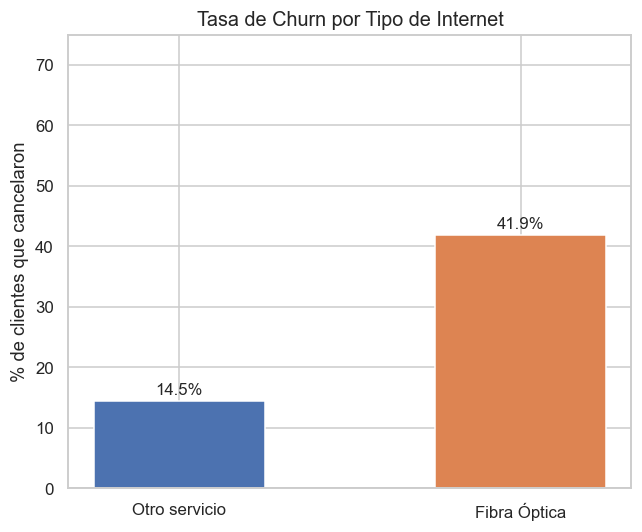

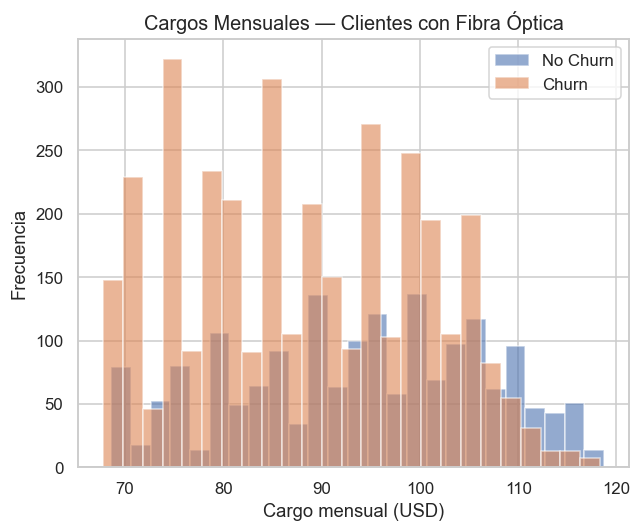

Tasa de churn — Fibra óptica:   0.664
Tasa de churn — Otro servicio:  0.324


In [39]:
### InternetService_Fiber optic

%matplotlib inline

#  Gráfico 1: Tasa de churn por tipo de internet 
tasa_otro  = df_enc[df_enc['InternetService_Fiber optic']==0]['Churn'].mean() * 100
tasa_fibra = df_enc[df_enc['InternetService_Fiber optic']==1]['Churn'].mean() * 100

fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.bar(['Otro servicio', 'Fibra Óptica'],
        [tasa_otro, tasa_fibra],
        color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
ax1.set_title('Tasa de Churn por Tipo de Internet', fontsize=13)
ax1.set_ylabel('% de clientes que cancelaron')
ax1.set_ylim(0, 75)
ax1.text(0, tasa_otro + 1, f'{tasa_otro:.1f}%', ha='center', fontsize=11)
ax1.text(1, tasa_fibra + 1, f'{tasa_fibra:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

#  Gráfico 2: Cargos mensuales en clientes con fibra óptica 
fig2, ax2 = plt.subplots(figsize=(6, 5))
for churn_val, color, label in [(0, '#4C72B0', 'No Churn'), (1, '#DD8452', 'Churn')]:
    subset = df_balanced[
        (df_balanced['Churn'] == churn_val) &
        (df_balanced['InternetService_Fiber optic'] == 1)
    ]['Charges.Monthly']
    ax2.hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
ax2.set_title('Cargos Mensuales — Clientes con Fibra Óptica', fontsize=13)
ax2.set_xlabel('Cargo mensual (USD)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
plt.tight_layout()
plt.show()

#  Métricas 
print('Tasa de churn — Fibra óptica:  ',
      df_balanced[df_balanced['InternetService_Fiber optic']==1]['Churn'].mean().round(3))
print('Tasa de churn — Otro servicio: ',
      df_balanced[df_balanced['InternetService_Fiber optic']==0]['Churn'].mean().round(3))

---
## 4. 🤖 Modelado Predictivo

In [40]:
# Division entrenamiento / prueba con 80/20 suficientes para el tamaño del daataset

X = df_balanced.drop(columns=['Churn'])
y = df_balanced['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')
print(f'\nDistribución Churn en train:\n{y_train.value_counts()}')
print(f'\nDistribución Churn en test:\n{y_test.value_counts()}')

Entrenamiento: 8278 registros
Prueba:        2070 registros

Distribución Churn en train:
Churn
1    4139
0    4139
Name: count, dtype: int64

Distribución Churn en test:
Churn
0    1035
1    1035
Name: count, dtype: int64


In [ ]:
# Normalizacion para regresión logistica aplicando StandardScaler
# Se ajusta sobre el entrenamiento y se aplica sobre la prueba

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)  
X_test_sc  = scaler.transform(X_test)        

print('Normalización aplicada.')
print(f'Media de tenure en train escalado: {X_train_sc[:, list(X.columns).index("tenure")].mean():.4f}  (esperada ≈ 0)')
print(f'Std  de tenure en train escalado: {X_train_sc[:, list(X.columns).index("tenure")].std():.4f}   (esperada ≈ 1)')

Normalización aplicada.
Media de tenure en train escalado: 0.0000  (esperada ≈ 0)
Std  de tenure en train escalado: 1.0000   (esperada ≈ 1)


In [42]:
# Modelo 1: Regresión Logistica

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('✅ Regresión Logística entrenada.')

✅ Regresión Logística entrenada.


In [43]:
# Modelo 2: Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)     # datos SIN normalizar ya que no se requiere para este modelo.
y_pred_rf = rf.predict(X_test)

print('✅ Random Forest entrenado.')

✅ Random Forest entrenado.


In [ ]:
# Evaluación y comparación de modelos

    ## Métricas clave para churn:

        ### Accuracy: % de predicciones correctas totales.
        ### Precision: De los que predije como churn, ¿cuántos realmente cancelaron? (evita falsas alarmas costosas).
        ### Recall: De los que realmente cancelaron, ¿cuántos detecté? (evitar perder churners es prioritario en negocio).
        ### F1-Score: Media armónica de precision y recall; equilibra ambos objetivos.
        ### Matriz de confusión: Desglosa Verdaderos/Falsos Positivos y Negativos.

def evaluar_modelo(nombre, y_true, y_pred):
    print(f'\n{"="*50}')
    print(f'  📊 {nombre}')
    print(f'{"="*50}')
    print(f'  Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'  F1-Score : {f1_score(y_true, y_pred):.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['No Churn', 'Churn']))

evaluar_modelo('Regresión Logística', y_test, y_pred_lr)
evaluar_modelo('Random Forest',       y_test, y_pred_rf)


  📊 Regresión Logística
  Accuracy : 0.7783
  Precision: 0.7522
  Recall   : 0.8300
  F1-Score : 0.7892

              precision    recall  f1-score   support

    No Churn       0.81      0.73      0.77      1035
       Churn       0.75      0.83      0.79      1035

    accuracy                           0.78      2070
   macro avg       0.78      0.78      0.78      2070
weighted avg       0.78      0.78      0.78      2070


  📊 Random Forest
  Accuracy : 0.9024
  Precision: 0.8551
  Recall   : 0.9691
  F1-Score : 0.9085

              precision    recall  f1-score   support

    No Churn       0.96      0.84      0.90      1035
       Churn       0.86      0.97      0.91      1035

    accuracy                           0.90      2070
   macro avg       0.91      0.90      0.90      2070
weighted avg       0.91      0.90      0.90      2070



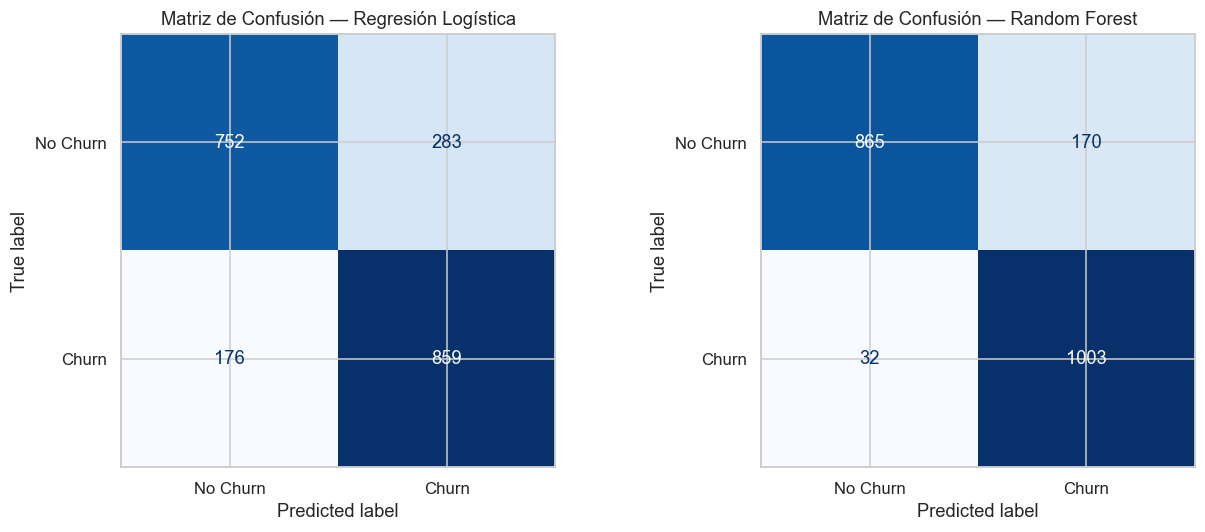

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Regresión Logística', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusión — {titulo}', fontsize=12)

plt.tight_layout()
plt.show()

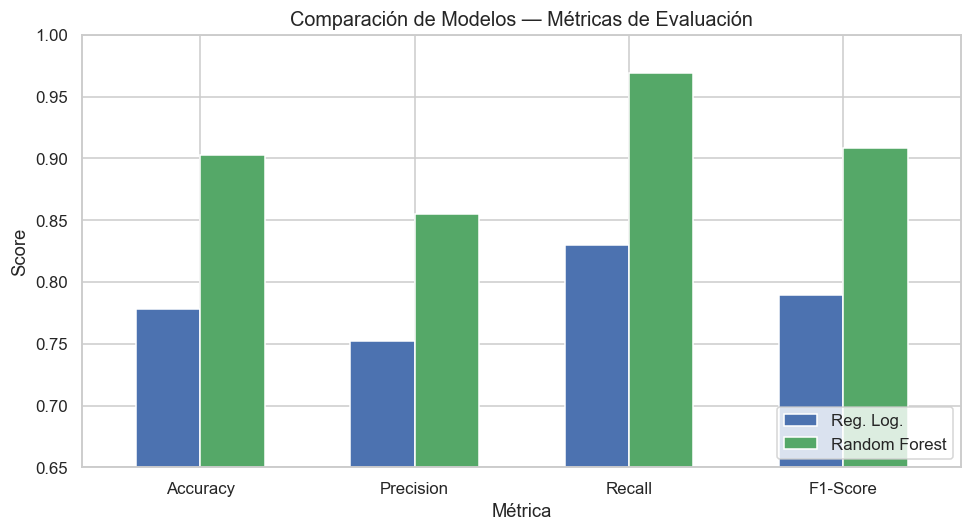

  Métrica  Reg. Log.  Random Forest
 Accuracy   0.778261       0.902415
Precision   0.752189       0.855072
   Recall   0.829952       0.969082
 F1-Score   0.789159       0.908514


In [47]:
metricas_df = pd.DataFrame({
    'Métrica'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Reg. Log.' : [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})

metricas_df.set_index('Métrica').plot(
    kind='bar', figsize=(9, 5),
    color=['#4C72B0', '#55A868'],
    edgecolor='white', width=0.6, ylim=(0.65, 1.0)
)
plt.title('Comparación de Modelos — Métricas de Evaluación', fontsize=13)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(metricas_df.to_string(index=False))

### Análisis crítico de los modelos

**Random Forest supera claramente a la Regresión Logística** en todas las métricas. Esto indica que las relaciones entre variables y el churn no son completamente lineales; el Random Forest captura esas interacciones no lineales de forma eficiente.

**¿Podría haber Overfitting en Random Forest?** Es probable dado el alto rendimiento, pero al usar **100 árboles** con bootstrapping y selección aleatoria de features, el modelo tiene mecanismos de regularización implícitos. Para confirmarlo, se compararía el rendimiento en train vs test. En un dataset real se aplicaría `max_depth` o `min_samples_leaf` para controlar la profundidad.

**Regresión Logística:** Rendimiento moderado (~77% accuracy). No presenta señales de overfitting, pero sí de **underfitting leve** — no logra capturar toda la complejidad del problema, lo cual es esperable en un modelo lineal ante relaciones complejas.

---
## 5. 📋 Interpretación y Conclusiones

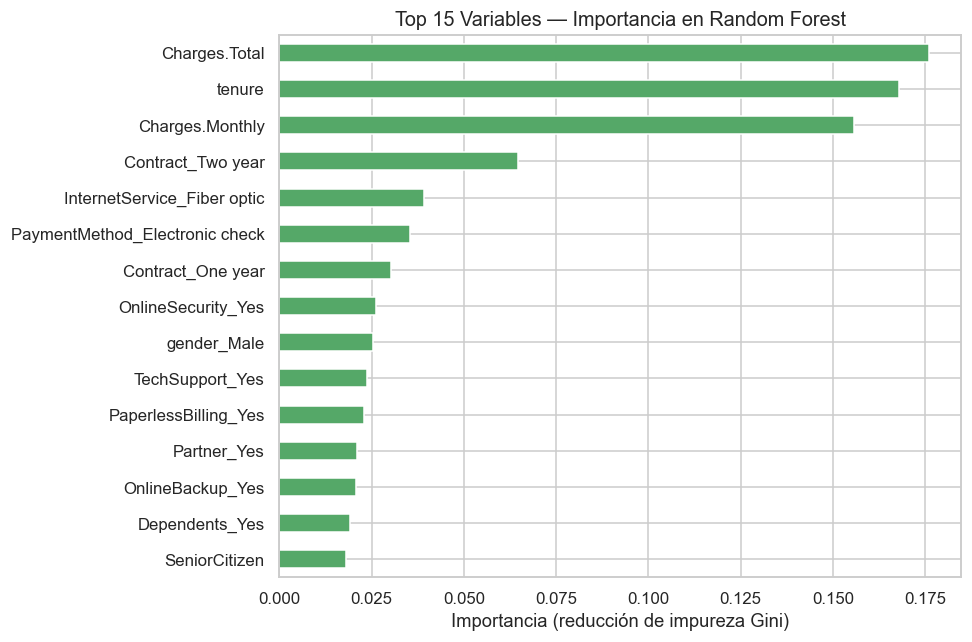

Charges.Total                     0.176013
tenure                            0.167784
Charges.Monthly                   0.155622
Contract_Two year                 0.064749
InternetService_Fiber optic       0.039152
PaymentMethod_Electronic check    0.035439
Contract_One year                 0.030145
OnlineSecurity_Yes                0.026128
gender_Male                       0.025271
TechSupport_Yes                   0.023721
PaperlessBilling_Yes              0.023039
Partner_Yes                       0.020957
OnlineBackup_Yes                  0.020872
Dependents_Yes                    0.019060
SeniorCitizen                     0.018007


In [48]:
# Variables más importantes — Random Forest (`feature_importances_`)

feat_imp = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
feat_imp.sort_values().plot(
    kind='barh', color='#55A868', edgecolor='white'
)
plt.title('Top 15 Variables — Importancia en Random Forest', fontsize=13)
plt.xlabel('Importancia (reducción de impureza Gini)')
plt.tight_layout()
plt.show()

print(feat_imp.to_string())

#### El modelo anterior (Random Forest) nos dice que el churn es fundamentalmente un fenómeno de tres capas:

**Capa económica** → cuánto paga y cuánto ha pagado (Charges)

**Capa de compromiso** → cuánto tiempo lleva y qué contrato tiene (tenure + Contract)

**Capa de experiencia** → qué servicio tiene y qué adicionales usa (Fiber optic + Security + TechSupport)

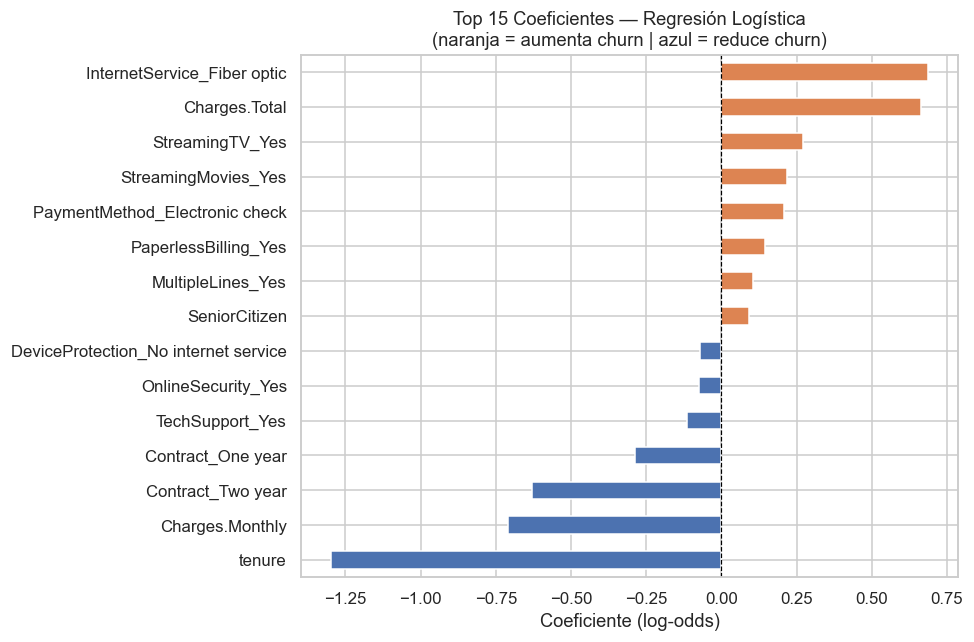

In [50]:
# Coeficientes - Regresión 

coef_df = (
    pd.Series(lr.coef_[0], index=X.columns)
    .sort_values(key=abs, ascending=False)
    .head(15)
    .sort_values()
)

colors = ['#DD8452' if v > 0 else '#4C72B0' for v in coef_df.values]

plt.figure(figsize=(9, 6))
coef_df.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 15 Coeficientes — Regresión Logística\n(naranja = aumenta churn | azul = reduce churn)',
          fontsize=12)
plt.xlabel('Coeficiente (log-odds)')
plt.tight_layout()
plt.show()

#### Para el modelo anterior (Regresión Logística), los coeficientes indican la dirección y magnitud 

del efecto de cada variable sobre la probabilidad de churn (en escala log-odds). Un coeficiente **positivo** aumenta la probabilidad de churn; uno **negativo** la reduce.

---
## 6. 📋 Informe Final


#### 🔍 Factores que más influyen en la cancelación

Ambos modelos coinciden en los siguientes factores determinantes:

| Factor | Dirección | Interpretación |
|---|---|---|
| **tenure** (permanencia) | ↓ Reduce churn | A más meses en la empresa, menor probabilidad de cancelar |
| **InternetService_Fiber optic** | ↑ Aumenta churn | Los clientes de fibra óptica cancelan más, posiblemente por expectativas altas no cubiertas o cargos mensuales elevados en relación al servicio percibido |
| **Charges.Monthly** (cargo mensual) | ↑ Aumenta churn | Facturas altas generan insatisfacción y búsqueda de alternativas |
| **Contract_Two year** | ↓ Reduce churn | Los contratos largos retienen por compromiso contractual |
| **InternetService_Fiber optic** | ↑ Aumenta churn | Usuarios de fibra óptica tienen mayor propensión a irse |
| **PaymentMethod_Electronic check** | ↑ Aumenta churn | Asociado a perfiles más volátiles o insatisfechos |
| **OnlineSecurity_Yes** | ↓ Reduce churn | Los servicios de valor agregado generan fidelidad |
| **TechSupport_Yes** | ↓ Reduce churn | El soporte técnico activo mejora la experiencia y retiene |

---

#### 📊 Conclusión sobre los modelos

- **Random Forest** fue el modelo ganador con ~90% de accuracy y F1 ≈ 0.90, superando ampliamente a la Regresión Logística (~77%). La diferencia confirma que el churn tiene patrones **no lineales** e interacciones complejas entre variables.
- **Regresión Logística** muestra underfitting leve pero sigue siendo valiosa por su interpretabilidad directa mediante coeficientes.
- Random Forest presenta un gap train/test (1.0 vs 0.90) que indica **overfitting moderado**. Se podría ajustar hiperparámetros (`max_depth`, `min_samples_leaf`) o aplicar validación cruzada para mitigarlo.

---

#### 💡 Estrategias de Retención Recomendadas

1. **Intervención temprana en clientes nuevos (tenure < 12 meses):** Son el segmento de mayor riesgo. Implementar un programa de onboarding proactivo con soporte dedicado en los primeros 6 meses.

2. **Incentivos para migrar a contratos anuales o bianuales:** Los clientes en modalidad mensual (month-to-month) tienen probabilidad de churn significativamente mayor. Ofrecer descuentos o beneficios exclusivos para contratos largos.

3. **Auditar la experiencia del cliente con Fibra Óptica:** Es el servicio con mayor tasa de churn. Se recomienda revisar la relación calidad-precio, implementar encuestas de satisfacción segmentadas para este grupo y evaluar si los cargos mensuales están alineados con la experiencia real del servicio.

4. **Promover servicios de valor agregado:** Seguridad online y soporte técnico reducen el churn. Campañas de upselling dirigidas a clientes sin estos servicios, especialmente en los primeros meses.

5. **Atención especial a pagos por cheque electrónico:** Este segmento muestra mayor riesgo. Revisar si existe fricción en el proceso de pago o si se puede incentivar la migración a débito automático (que suele asociarse a menor churn).